# LightGBM Feature Engineering Experiment

Third-place-inspired, simple and reproducible feature engineering for the Santander customer satisfaction task.

Scope for this notebook:
- Keep the existing LightGBM setup and CV protocol.
- Add only sparsity/activity features and `var38` treatment.
- Do not add PCA, KMeans, t-SNE, likelihood/target encoding, or post-processing.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_predict
from sklearn.metrics import roc_auc_score, roc_curve

try:
    from lightgbm import LGBMClassifier
    _LGB_OK = True
except Exception:
    try:
        import sys, subprocess
        subprocess.check_call([sys.executable, "-m", "pip", "install", "lightgbm", "--quiet"])
        from lightgbm import LGBMClassifier
        _LGB_OK = True
        print("[Info] lightgbm installed successfully.")
    except Exception as e:
        print(f"[Info] Could not install lightgbm: {e}")
        _LGB_OK = False

RNG_SEED = 42
np.random.seed(RNG_SEED)

warnings.filterwarnings(
    "ignore",
    message="X does not have valid feature names, but LGBMClassifier was fitted with feature names",
    category=UserWarning,
)


In [2]:
# -----------------------------
# 1) Load dataset
# -----------------------------
train = pd.read_csv("train_clean.csv")
test = pd.read_csv("test_clean.csv")

y = train["TARGET"].values
train_id = train["ID"].values
test_id = test["ID"].values

print(f"Raw train: {train.shape[0]} rows, {train.shape[1]} columns")
print(f"Raw test:  {test.shape[0]} rows, {test.shape[1]} columns")
print(f"Target rate: {y.mean()*100:.2f}%")


Raw train: 76020 rows, 308 columns
Raw test:  75818 rows, 307 columns
Target rate: 3.96%


In [3]:
# -----------------------------
# 2) Baseline from current best LightGBM notebook
# -----------------------------
# Existing Model_LightGBM.ipynb uses this same model search and includes n_zeros.
# Recorded OOF AUC from that notebook: 0.83749.
BASELINE_RECORDED_OOF_AUC = 0.83749
BASELINE_RECORDED_GRIDSEARCH_AUC = 0.83767

print(f"LightGBM baseline recorded OOF AUC: {BASELINE_RECORDED_OOF_AUC:.5f}")
print(f"LightGBM baseline recorded GridSearch CV AUC: {BASELINE_RECORDED_GRIDSEARCH_AUC:.5f}")


LightGBM baseline recorded OOF AUC: 0.83749
LightGBM baseline recorded GridSearch CV AUC: 0.83767


In [4]:
# -----------------------------
# 3) Third-place-inspired simple FE
# -----------------------------
train_fe = train.copy()
test_fe = test.copy()

feature_cols = [c for c in train_fe.columns if c not in ["ID", "TARGET"]]

# 1. Sparsity / activity features
train_fe["zero_count"] = (train_fe[feature_cols] == 0).sum(axis=1)
test_fe["zero_count"] = (test_fe[feature_cols] == 0).sum(axis=1)

train_fe["nonzero_count"] = (train_fe[feature_cols] != 0).sum(axis=1)
test_fe["nonzero_count"] = (test_fe[feature_cols] != 0).sum(axis=1)

# 2. var38 special treatment
peak = 117310.979016494

if "var38" in train_fe.columns:
    train_fe["var38_is_peak"] = (train_fe["var38"] == peak).astype(int)
    test_fe["var38_is_peak"] = (test_fe["var38"] == peak).astype(int)

    train_fe["var38_log"] = np.log1p(train_fe["var38"])
    test_fe["var38_log"] = np.log1p(test_fe["var38"])

    train_fe.loc[train_fe["var38"] == peak, "var38_log"] = 0
    test_fe.loc[test_fe["var38"] == peak, "var38_log"] = 0

added_features = [c for c in ["zero_count", "nonzero_count", "var38_is_peak", "var38_log"] if c in train_fe.columns]
print("Added features:", added_features)
print(train_fe[added_features].head())


Added features: ['zero_count', 'nonzero_count', 'var38_is_peak', 'var38_log']
   zero_count  nonzero_count  var38_is_peak  var38_log
0         292             14              0  10.576589
1         266             40              0  10.805254
2         277             29              0  11.117432
3         248             58              0  11.066779
4         256             50              1   0.000000


In [5]:
# -----------------------------
# 4) Build matrices
# -----------------------------
X_df = train_fe.drop(columns=["ID", "TARGET"])
X_test_df = test_fe.drop(columns=["ID"])

common_cols = [c for c in X_df.columns if c in X_test_df.columns]
X_df = X_df[common_cols]
X_test_df = X_test_df[common_cols]

X = X_df.values
X_test = X_test_df.values

print(f"Train FE matrix: {X.shape[0]} rows, {X.shape[1]} features")
print(f"Test FE matrix:  {X_test.shape[0]} rows, {X_test.shape[1]} features")


Train FE matrix: 76020 rows, 310 features
Test FE matrix:  75818 rows, 310 features


In [6]:
# -----------------------------
# 5) Grid Search with 5-Fold CV
# -----------------------------
if not _LGB_OK:
    raise ImportError("lightgbm is required to run this notebook.")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RNG_SEED)

lgb_clf = LGBMClassifier(
    random_state=RNG_SEED,
    n_jobs=-1,
    verbose=-1,
)

param_grid = {
    "n_estimators": [100, 300, 500],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.03, 0.1],
    "num_leaves": [15, 31],
}

gs = GridSearchCV(
    estimator=lgb_clf,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    refit=True,
    n_jobs=-1,
)
gs.fit(X, y)

best_model = gs.best_estimator_
print(f"[CV] Best params: {gs.best_params_}")
print(f"[CV] Best CV AUC: {gs.best_score_:.5f}")


[CV] Best params: {'learning_rate': 0.03, 'max_depth': 3, 'n_estimators': 300, 'num_leaves': 15}
[CV] Best CV AUC: 0.83840


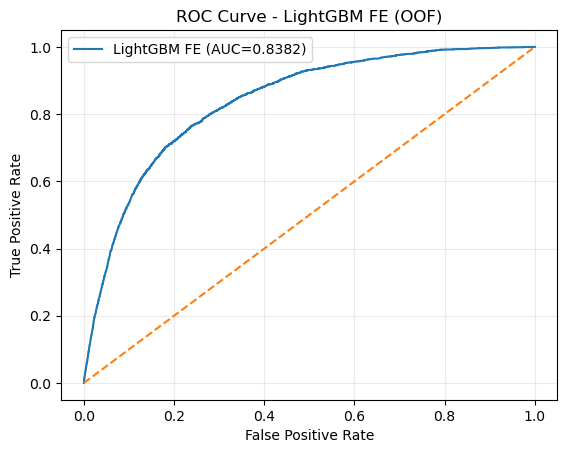

[OOF] LightGBM baseline AUC: 0.83749
[OOF] LightGBM + zero/nonzero/var38 AUC: 0.83825
[OOF] Delta vs recorded baseline: +0.00076


In [7]:
# -----------------------------
# 6) Evaluate: ROC curve using CV predictions
# -----------------------------
oof = cross_val_predict(best_model, X, y, cv=cv, method="predict_proba")[:, 1]
fe_oof_auc = roc_auc_score(y, oof)

fpr, tpr, _ = roc_curve(y, oof)
plt.figure()
plt.plot(fpr, tpr, label=f"LightGBM FE (AUC={fe_oof_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - LightGBM FE (OOF)")
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

print(f"[OOF] LightGBM baseline AUC: {BASELINE_RECORDED_OOF_AUC:.5f}")
print(f"[OOF] LightGBM + zero/nonzero/var38 AUC: {fe_oof_auc:.5f}")
print(f"[OOF] Delta vs recorded baseline: {fe_oof_auc - BASELINE_RECORDED_OOF_AUC:+.5f}")


In [8]:
# -----------------------------
# 7) Generate submission
# -----------------------------
y_test_pred = best_model.predict_proba(X_test)[:, 1]

sub = pd.DataFrame({
    "ID": test_id,
    "TARGET": y_test_pred,
})
sub.to_csv("submission_lightgbm_fe.csv", index=False)

print("Saved: submission_lightgbm_fe.csv")
print(f"Expected Kaggle LB AUC proxy from OOF: ~{fe_oof_auc:.4f}")
sub.head()


Saved: submission_lightgbm_fe.csv
Expected Kaggle LB AUC proxy from OOF: ~0.8382


,ID,TARGET
0,2,0.058551
1,5,0.057722
2,6,0.002650
3,7,0.012189
4,9,0.002773


## Experiment Log

| Model | OOF AUC | Kaggle Public LB | Kaggle Private LB | Notes |
|---|---:|---:|---:|---|
| LightGBM baseline | 0.83749 | TBD | TBD | Existing `Model_LightGBM.ipynb`; same LightGBM grid and 5-fold CV, recorded OOF. |
| LightGBM + zero/nonzero/var38 | 0.83825 | 0.82392 | 0.83777 | Adds only `zero_count`, `nonzero_count`, `var38_is_peak`, `var38_log`. |

Kaggle LB from `submission_lightgbm_fe.csv`: Public 0.82392, Private 0.83777. Current local OOF delta vs baseline: +0.00076.
